In [1]:
import xarray as xr
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def load_nc_data(root, file_name):
    """load nc data and select the region of interest
    
    Returns:
        data: a xr.dataarray of shape (time, lat, lon)
    """
    data_file = root + file_name
    var_name = 'aod'
    with xr.open_dataset(data_file) as data_ds:
        data = data_ds[var_name]
        lat = data_ds.lat
        lon = data_ds.lon
    return data.values, lat.values, lon.values

class NcDataset(Dataset):
    def __init__(self, root, file_name, n_frames_input, n_frames_output):
        super().__init__()
        self.datas, self.lats, self.lons = load_nc_data(root, file_name)
        self.num_frames_input = n_frames_input
        self.num_frames_output = n_frames_output
        self.num_frames = n_frames_input + n_frames_output
        print('Loaded {} samples'.format(self.__len__()))

    def __getitem__(self, idx):
        # data = self.datas[index:index+self.num_frames]
        data = self.datas[idx*self.num_frames:(idx+1)*self.num_frames]
        inputs = data[:self.num_frames_input]
        targets = data[self.num_frames_input:]
        inputs = inputs[..., np.newaxis]
        targets = targets[..., np.newaxis]

        lat = self.lats[idx*self.num_frames:(idx+1)*self.num_frames]
        lon = self.lons[idx*self.num_frames:(idx+1)*self.num_frames]
        inputs_lat = lat[:self.num_frames_input]
        inputs_lon = lon[:self.num_frames_input]
        targets_lat = lat[self.num_frames_input:]
        targets_lon = lon[self.num_frames_input:]
        inputs_lat = inputs_lat[..., np.newaxis]
        inputs_lon = inputs_lon[..., np.newaxis]
        targets_lat = targets_lat[..., np.newaxis]
        targets_lon = targets_lon[..., np.newaxis]

        # replace nan values with 0
        # inputs = np.nan_to_num(inputs)
        # targets = np.nan_to_num(targets)
        # replace negative values with 0
        inputs[inputs < 0] = 0.0
        targets[targets < 0] = 0.0
        inputs = torch.from_numpy(inputs).permute(0, 3, 1, 2).float().contiguous()
        targets = torch.from_numpy(targets).permute(0, 3, 1, 2).float().contiguous()
        inputs_lat = torch.from_numpy(inputs_lat).permute(0, 3, 1, 2).float().contiguous()
        inputs_lon = torch.from_numpy(inputs_lon).permute(0, 3, 1, 2).float().contiguous()
        targets_lat = torch.from_numpy(targets_lat).permute(0, 3, 1, 2).float().contiguous()
        targets_lon = torch.from_numpy(targets_lon).permute(0, 3, 1, 2).float().contiguous()
        return idx, targets, inputs, inputs_lat, inputs_lon, targets_lat, targets_lon
    

    def __len__(self):
        return self.datas.shape[0] // self.num_frames

In [3]:
data_set = NcDataset(root='./data/',
                        file_name='saved_aod_20230101_latlon_interp_cubic.nc',
                        n_frames_input=6,
                        n_frames_output=6)
batch_size = 5
data_loader = DataLoader(data_set, batch_size=batch_size, shuffle=False)
# print the shape of the first batch
for batch_ind, (i, targets, inputs, inputs_lat, inputs_lon, targets_lat, targets_lon) in enumerate(data_loader):
    print('batch_ind: {}'.format(batch_ind))
    print('i: {}'.format(i))
    print('targets: {}'.format(targets.shape))
    print('inputs: {}'.format(inputs.shape))
    print('inputs_lat: {}'.format(inputs_lat.shape))
    print('inputs_lon: {}'.format(inputs_lon.shape))
    print('targets_lat: {}'.format(targets_lat.shape))
    print('targets_lon: {}'.format(targets_lon.shape))
    break

Loaded 417 samples
batch_ind: 0
i: tensor([0, 1, 2, 3, 4])
targets: torch.Size([5, 6, 1, 64, 64])
inputs: torch.Size([5, 6, 1, 64, 64])
inputs_lat: torch.Size([5, 6, 1, 64, 64])
inputs_lon: torch.Size([5, 6, 1, 64, 64])
targets_lat: torch.Size([5, 6, 1, 64, 64])
targets_lon: torch.Size([5, 6, 1, 64, 64])


Using device cpu.
torch.Size([5, 6, 1, 64, 64]) torch.Size([5, 6, 1, 64, 64]) tensor(1.6089) tensor(0.)


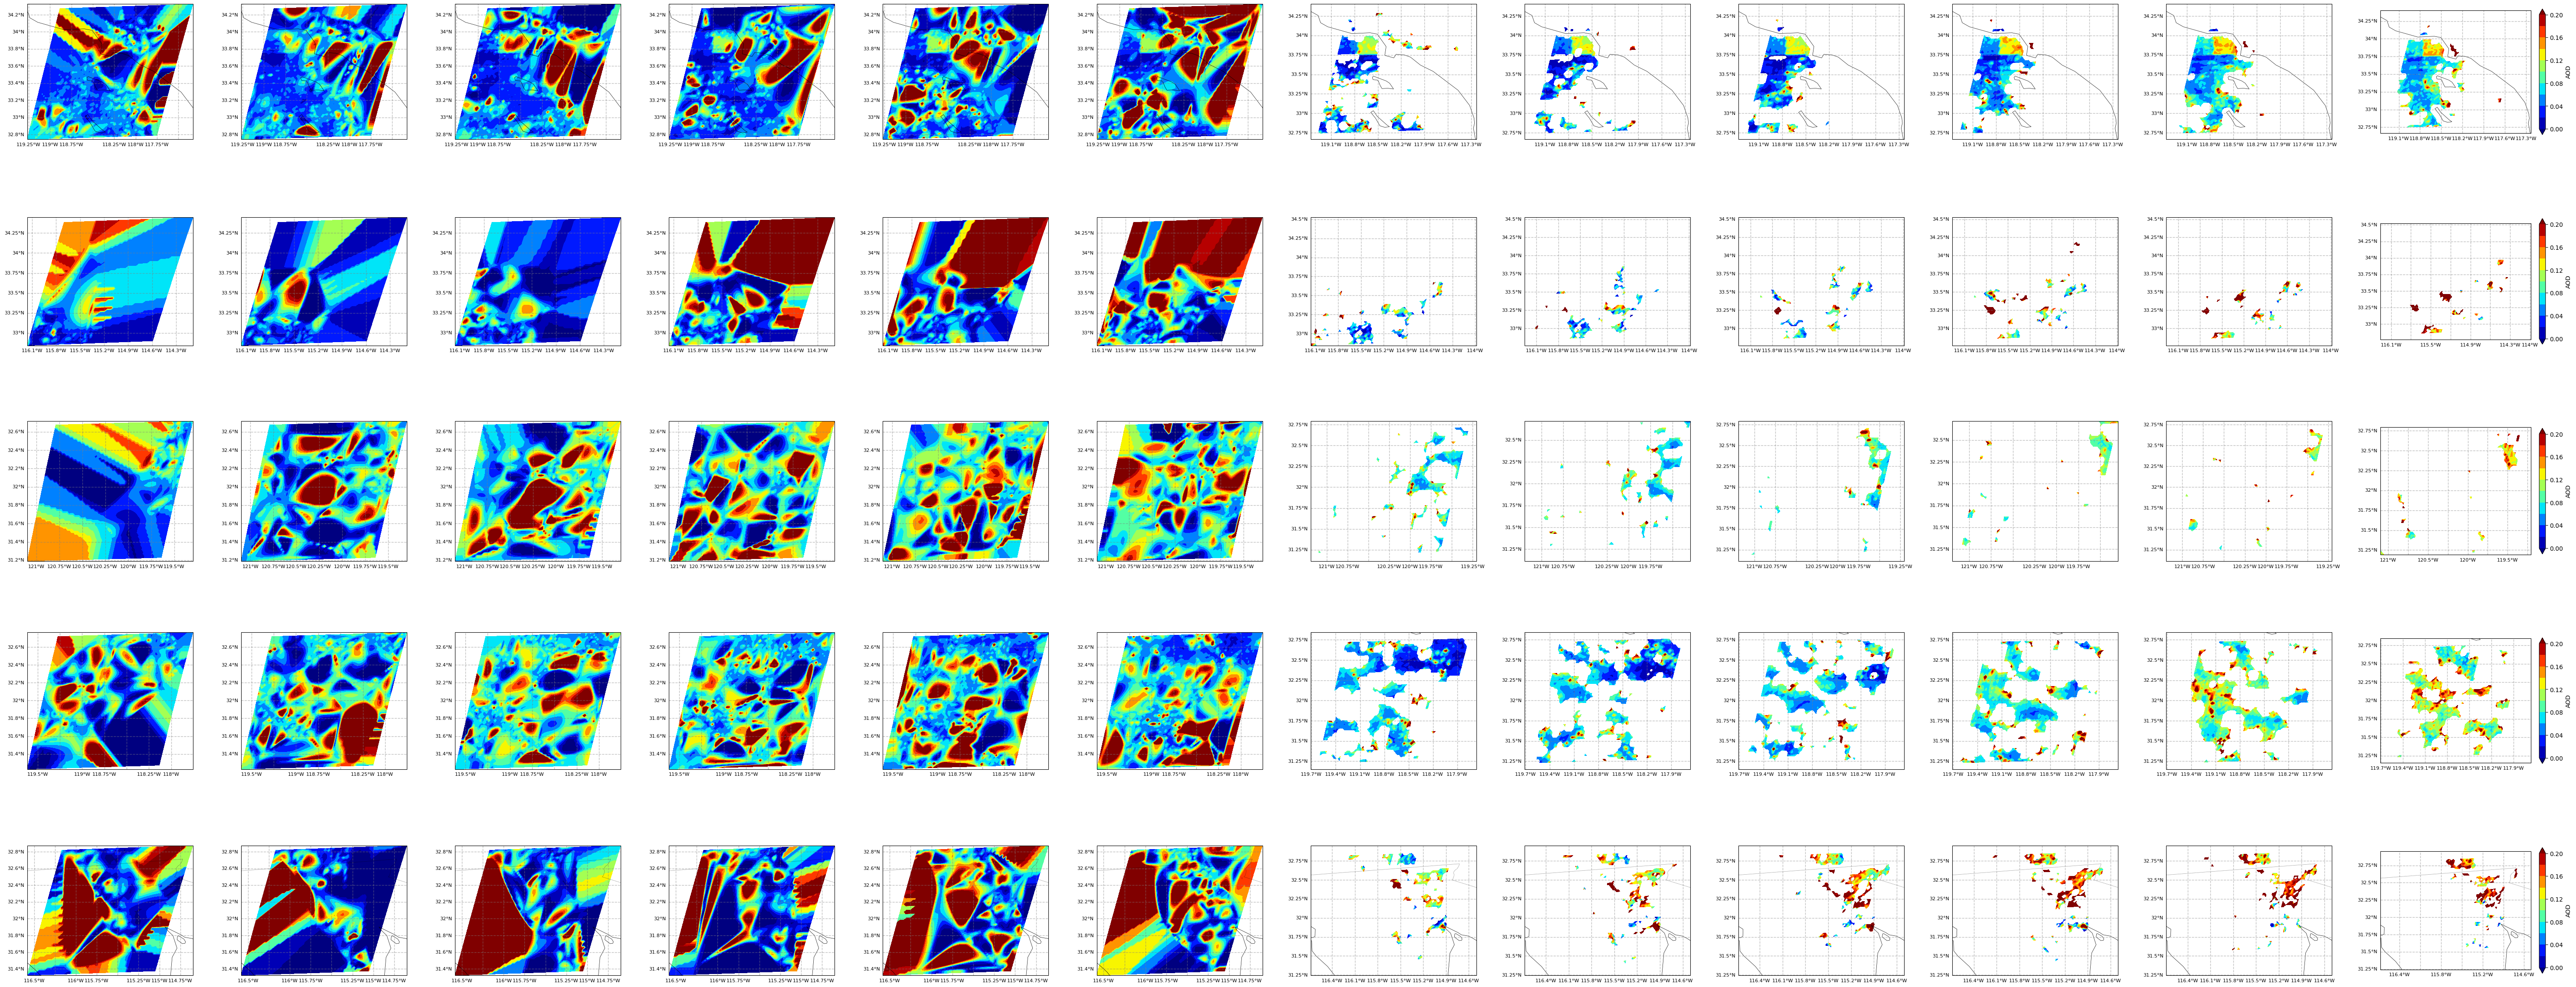

In [4]:
# choose device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device {}.".format(device))
# plot the first batch, adding lat and lon as images coordinates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

for batch_idx, (i, targets, inputs, inputs_lat, inputs_lon, targets_lat, targets_lon) in enumerate(data_loader):
    inputs = inputs.float().to(device)
    targets = targets.float().to(device)
    inputs_lat = inputs_lat.float().to(device)
    inputs_lon = inputs_lon.float().to(device)
    targets_lat = targets_lat.float().to(device)
    targets_lon = targets_lon.float().to(device)
    print(inputs.shape, targets.shape, inputs.max(), inputs.min())

    images = torch.cat([inputs, targets], dim=1)
    lats = torch.cat([inputs_lat, targets_lat], dim=1)
    lons = torch.cat([inputs_lon, targets_lon], dim=1)

    num_time_steps = inputs.shape[1]

    # Define the map projection
    projection = ccrs.PlateCarree()

    # Create subplots with the cartopy projection
    fig, axarr = plt.subplots(
        nrows=images.shape[0],
        ncols=images.shape[1],
        figsize=(images.shape[1] * batch_size, images.shape[0] * batch_size),
        subplot_kw={'projection': projection}
    )
    # levels: 0 - 0.2, 11 levels
    levels = np.linspace(0, 0.2, 11)
    for b in range(images.shape[0]):
        for n in range(images.shape[1]):
            ax = axarr[b][n]
            plot_img = images[b, n, 0]
            lats_img = lats[b, n, 0]
            lons_img = lons[b, n, 0]

            # Plot the data
            cs = ax.contourf(
                lons_img, lats_img, plot_img,
                transform=projection, cmap='jet', levels=levels, extend='both'
            )

            # Add geographic features and labeled gridlines
            ax.coastlines(resolution='50m', color='black', linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

            gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.xformatter = LongitudeFormatter()
            gl.yformatter = LatitudeFormatter()
            gl.xlabel_style = {'size': 8}
            gl.ylabel_style = {'size': 8}
        # Add a colorbar
        # Add a colorbar, make it shorter by using 'fraction' and 'shrink'
        cbar = plt.colorbar(cs, ax=ax, orientation='vertical', pad=0.05, fraction=0.04, shrink=0.6)
        cbar.set_label('AOD')

    plt.tight_layout(pad=3.0)
    plt.show()

    break

In [12]:
# load the trained model
import os
from encoder import Encoder
from decoder import Decoder
from model import ED
from net_params import convlstm_encoder_params, convlstm_decoder_params, convgru_encoder_params, convgru_decoder_params


def load_model(base_cell='convlstm'):
    TIMESTAMP = "2025-08-07T05-29-05"
    checkpoints_dir = f'save_model/{TIMESTAMP}_{base_cell}/'
    all_checkpoints = os.listdir(checkpoints_dir)
    all_checkpoints.sort()
    print(all_checkpoints)

    # initialize the network
    if base_cell == 'convlstm':
        convlstm_bool = True
    elif base_cell == 'convgru':
        convlstm_bool = False
    else:
        raise ValueError(f"Invalid base cell: {base_cell}")
    encoder_params = convlstm_encoder_params if convlstm_bool else convgru_encoder_params
    decoder_params = convlstm_decoder_params if convlstm_bool else convgru_decoder_params
    encoder = Encoder(encoder_params[0], encoder_params[1]).to(device)
    decoder = Decoder(decoder_params[0], decoder_params[1]).to(device)
    net = ED(encoder, decoder)
    net = net.to(device)
    # load the checkpoint
    if torch.cuda.is_available():
        model_info = torch.load(os.path.join(checkpoints_dir, all_checkpoints[0]))
    else:
        model_info = torch.load(os.path.join(checkpoints_dir, all_checkpoints[0]), map_location=torch.device('cpu'))
    net.load_state_dict(model_info['state_dict'])
    return net

In [13]:
# perform inference and save the results
net_gru = load_model(base_cell='convgru')
# net_lstm = load_model(base_cell='convlstm')
for batch_idx, (i, targets, inputs, inputs_lat, inputs_lon, targets_lat, targets_lon) in enumerate(data_loader):
    # only do the first 1 batches (5 samples)
    if batch_idx == 1:
        break
    print('batch_idx: {}'.format(batch_idx))
    inputs = inputs.float().to(device)
    targets = targets.float().to(device)
    inputs_lat = inputs_lat.float().to(device)
    inputs_lon = inputs_lon.float().to(device)
    targets_lat = targets_lat.float().to(device)
    targets_lon = targets_lon.float().to(device)

    outputs_gru = net_gru(inputs)
    # outputs_lstm = net_lstm(inputs)
    # save to file (npy format)
    save_inputs = inputs.cpu().detach().numpy().squeeze(2).reshape(-1, 64, 64)
    save_targets = targets.cpu().detach().numpy().squeeze(2).reshape(-1, 64, 64)
    save_outputs_gru = outputs_gru.cpu().detach().numpy().squeeze(2).reshape(-1, 64, 64)
    # save_outputs_lstm = outputs_lstm.cpu().detach().numpy().squeeze(2).reshape(-1, 64, 64)
    # save the lat and lon as well
    save_inputs_lat = inputs_lat.cpu().detach().numpy().squeeze(2).reshape(-1, 64, 64)
    save_inputs_lon = inputs_lon.cpu().detach().numpy().squeeze(2).reshape(-1, 64, 64)
    save_targets_lat = targets_lat.cpu().detach().numpy().squeeze(2).reshape(-1, 64, 64)
    save_targets_lon = targets_lon.cpu().detach().numpy().squeeze(2).reshape(-1, 64, 64)

    np.save('./data/save_inputs_{}-{}.npy'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1), save_inputs)
    np.save('./data/save_targets_{}-{}.npy'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1), save_targets)
    np.save('./data/save_outputs_gru_{}-{}.npy'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1), save_outputs_gru)
    # np.save('./data/save_outputs_lstm_{}-{}.npy'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1), save_outputs_lstm)
    np.save('./data/save_inputs_lat_{}-{}.npy'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1), save_inputs_lat)
    np.save('./data/save_inputs_lon_{}-{}.npy'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1), save_inputs_lon)
    np.save('./data/save_targets_lat_{}-{}.npy'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1), save_targets_lat)
    np.save('./data/save_targets_lon_{}-{}.npy'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1), save_targets_lon)
    # print the saved batch range
    print('saved batch {}-{}'.format(batch_idx*batch_size, (batch_idx+1)*batch_size-1))

['checkpoint.pth']
batch_idx: 0


/var/folders/91/vy36ykpj2v95bksxf2pglsy80000gn/T/ipykernel_59907/1641432476.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_info = torch.load(os.path.join(checkpo

saved batch 0-4


save_inputs_data shape: (30, 64, 64)


/var/folders/91/vy36ykpj2v95bksxf2pglsy80000gn/T/ipykernel_59907/2836312327.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)


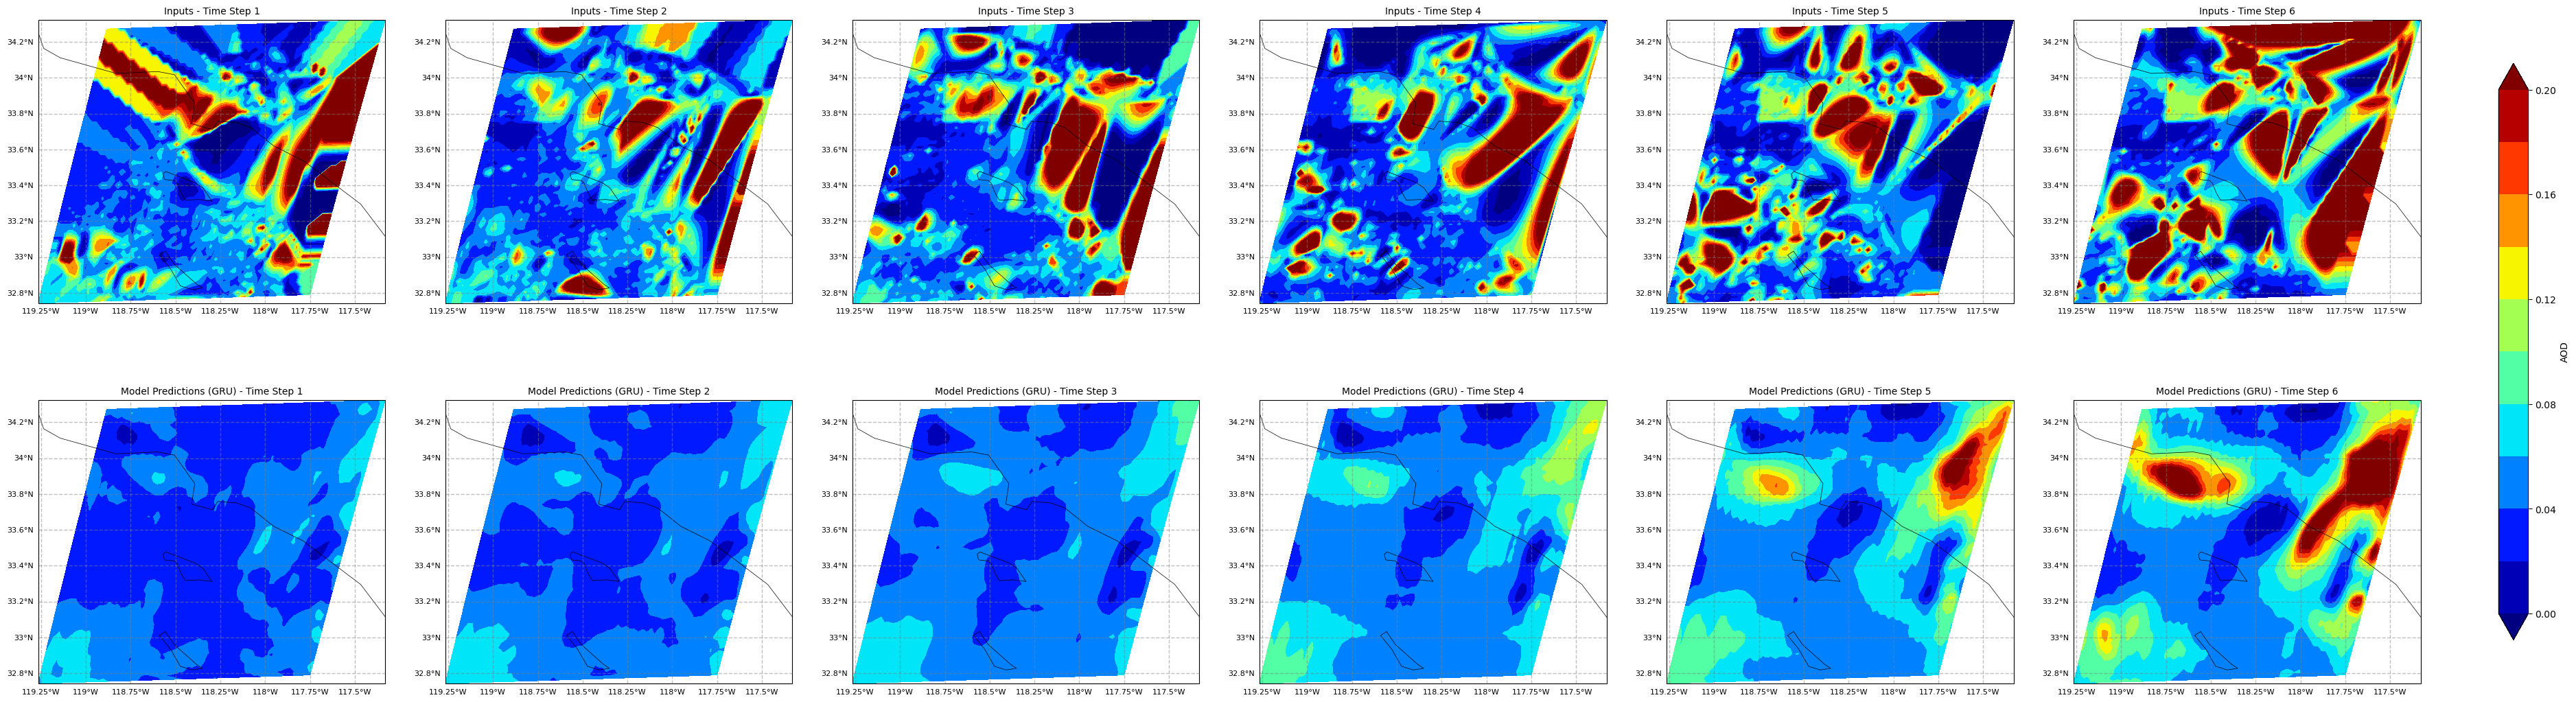

In [14]:
# plot some sample
to_plot_sample_idx = 0 # define which sample to plot, this will plot the 1st (index=0) sample
# load inputs and model predictions
save_inputs_data = np.load('./data/save_inputs_0-4.npy')
save_gru_data = np.load('./data/save_outputs_gru_0-4.npy')
# save_lstm_data = np.load('./data/save_outputs_lstm_0-4.npy')
print('save_inputs_data shape:', save_inputs_data.shape)

# load lat and lon
save_inputs_lat = np.load('./data/save_inputs_lat_0-4.npy')
save_inputs_lon = np.load('./data/save_inputs_lon_0-4.npy')
save_targets_lat = np.load('./data/save_targets_lat_0-4.npy')
save_targets_lon = np.load('./data/save_targets_lon_0-4.npy')

save_inputs_data = save_inputs_data[to_plot_sample_idx*6:(to_plot_sample_idx+1)*6, ...]
save_gru_data = save_gru_data[to_plot_sample_idx*6:(to_plot_sample_idx+1)*6, ...]

save_inputs_lat = save_inputs_lat[to_plot_sample_idx*6:(to_plot_sample_idx+1)*6, ...]
save_inputs_lon = save_inputs_lon[to_plot_sample_idx*6:(to_plot_sample_idx+1)*6, ...]
save_targets_lat = save_targets_lat[to_plot_sample_idx*6:(to_plot_sample_idx+1)*6, ...]
save_targets_lon = save_targets_lon[to_plot_sample_idx*6:(to_plot_sample_idx+1)*6, ...]

projection = ccrs.PlateCarree()
# Create subplots with the cartopy projection
fig, axarr = plt.subplots(
    nrows=2,
    ncols=6,
    figsize=(6*6, 2*6),
    subplot_kw={'projection': projection}
)
# levels: 0 - 0.2, 11 levels
levels = np.linspace(0, 0.2, 11)
for b in range(6):
    inputs_img = save_inputs_data[b]
    gru_img = save_gru_data[b]
    inputs_lat_img = save_inputs_lat[b]
    inputs_lon_img = save_inputs_lon[b]
    targets_lat_img = save_targets_lat[b]
    targets_lon_img = save_targets_lon[b]
    for k in range(2):
        ax = axarr[k][b]
        if k == 0:
            # Plot the inputs
            plot_img = inputs_img
            lats_img = inputs_lat_img
            lons_img = inputs_lon_img
            title = 'Inputs'
        else:
            # Plot the model predictions
            plot_img = gru_img
            lats_img = targets_lat_img
            lons_img = targets_lon_img
            title = 'Model Predictions (GRU)'
        # Plot the data
        cs = ax.contourf(lons_img, lats_img, plot_img,
                         transform=projection, cmap='jet', levels=levels, extend='both')
        # Add geographic features and labeled gridlines
        ax.coastlines(resolution='50m', color='black', linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
        gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()
        gl.xlabel_style = {'size': 8}
        gl.ylabel_style = {'size': 8}
        ax.set_title(title + f' - Time Step {b+1}', fontsize=10)
# Add a colorbar
# Add a single colorbar on the right side of all subplots
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([1.02, 0.15, 0.012, 0.7])  # [left, bottom, width, height]
cbar = plt.colorbar(cs, cax=cbar_ax)
cbar.set_label('AOD')
plt.tight_layout(pad=3.0)
plt.show()

Plotting Batch 0...
Plotting Sample 0 in batch 0...


/var/folders/91/vy36ykpj2v95bksxf2pglsy80000gn/T/ipykernel_59907/4276503074.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)


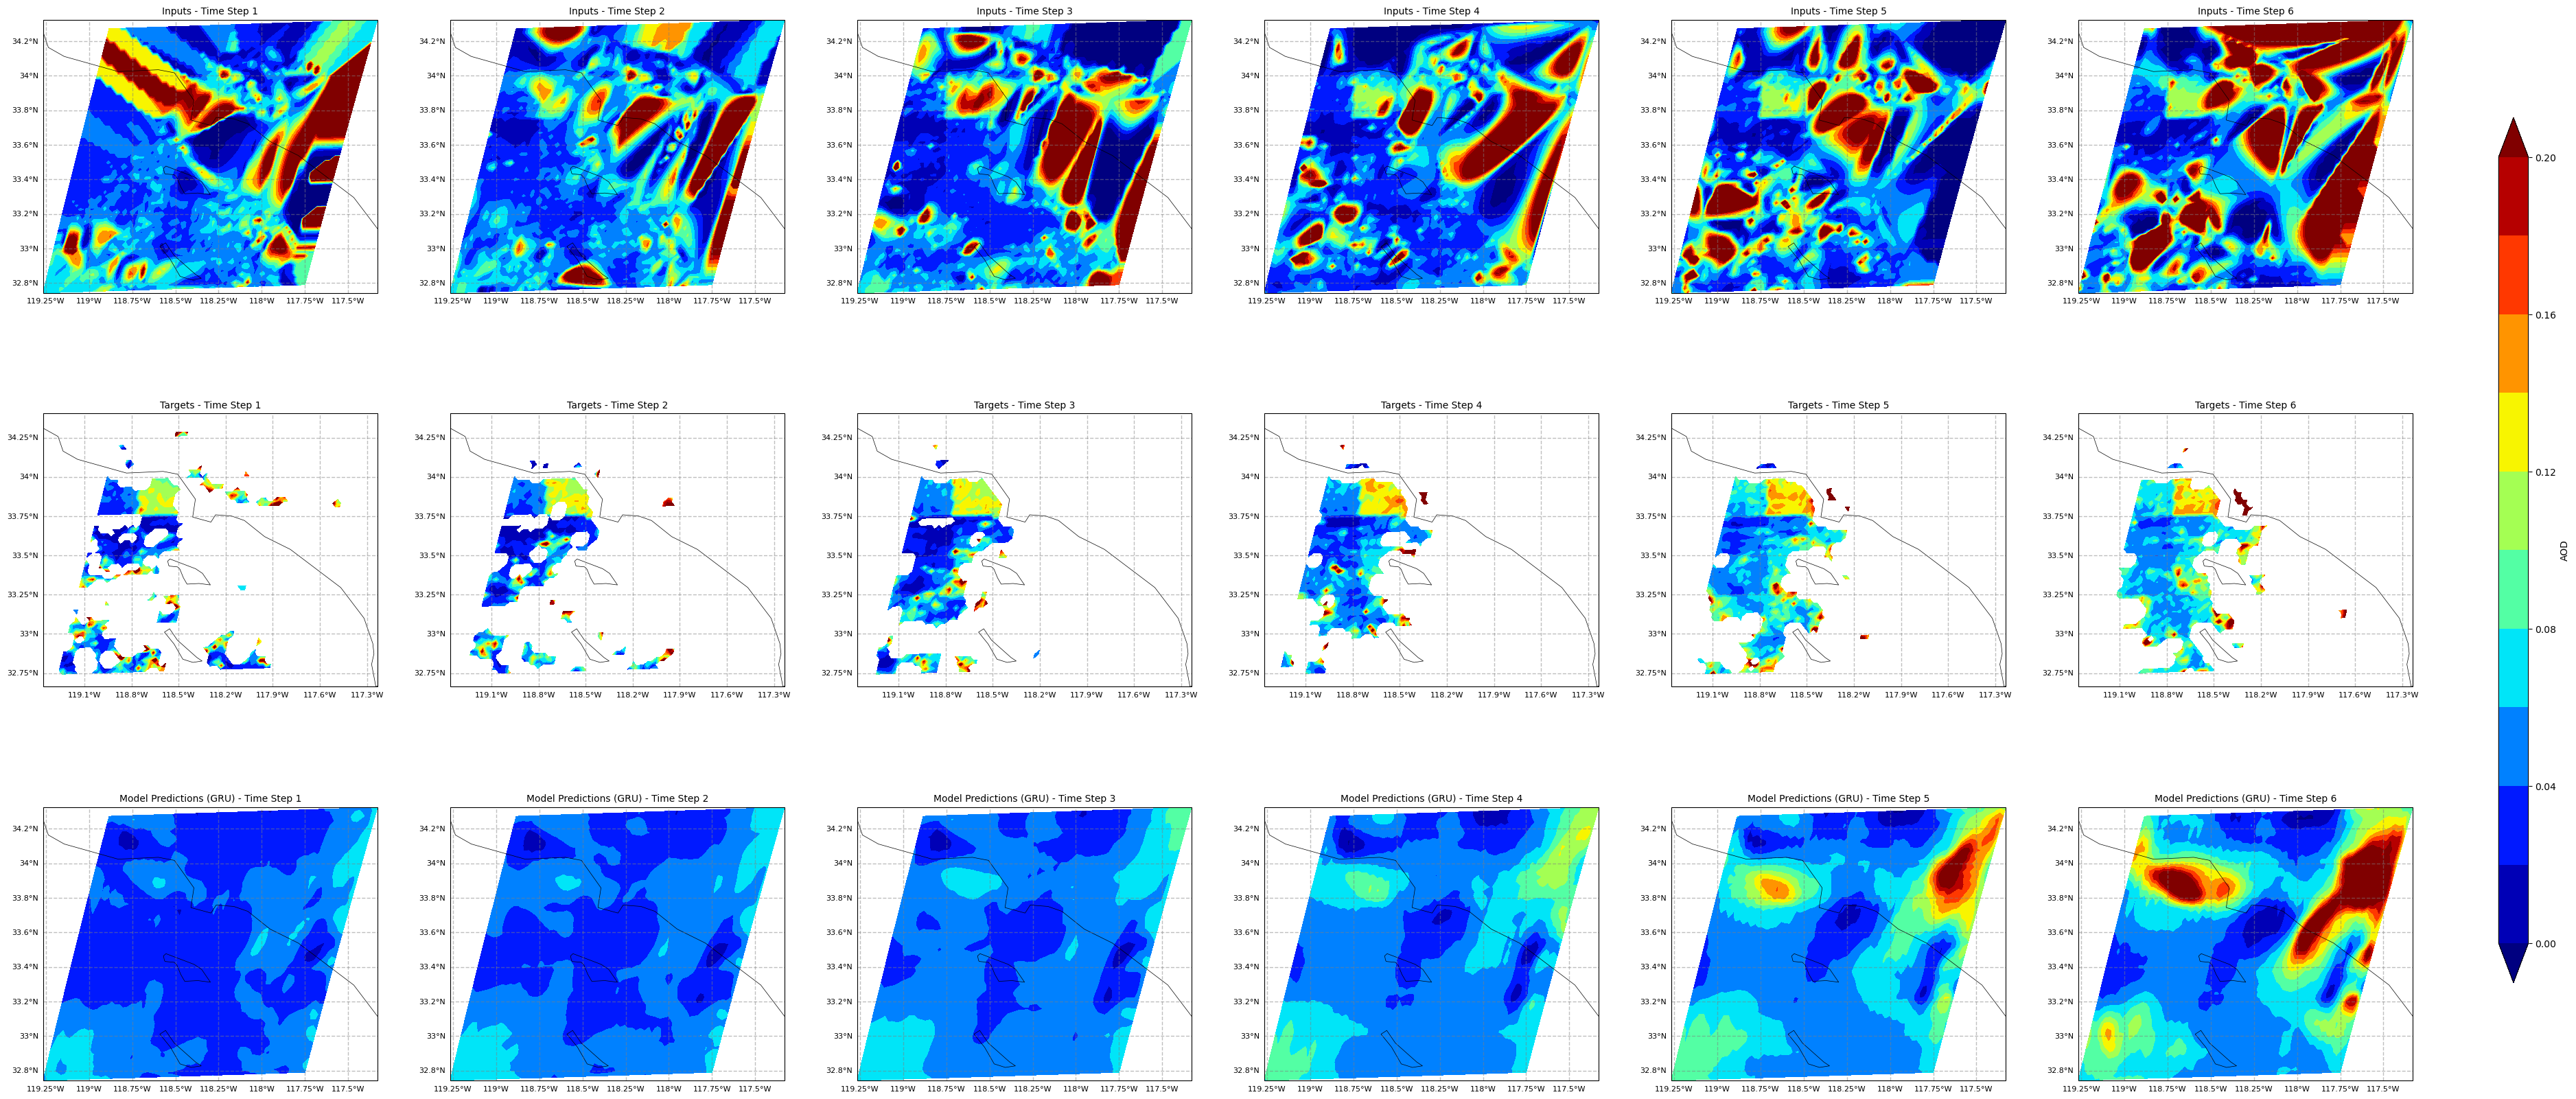

Plotting Sample 1 in batch 0...


/var/folders/91/vy36ykpj2v95bksxf2pglsy80000gn/T/ipykernel_59907/4276503074.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)


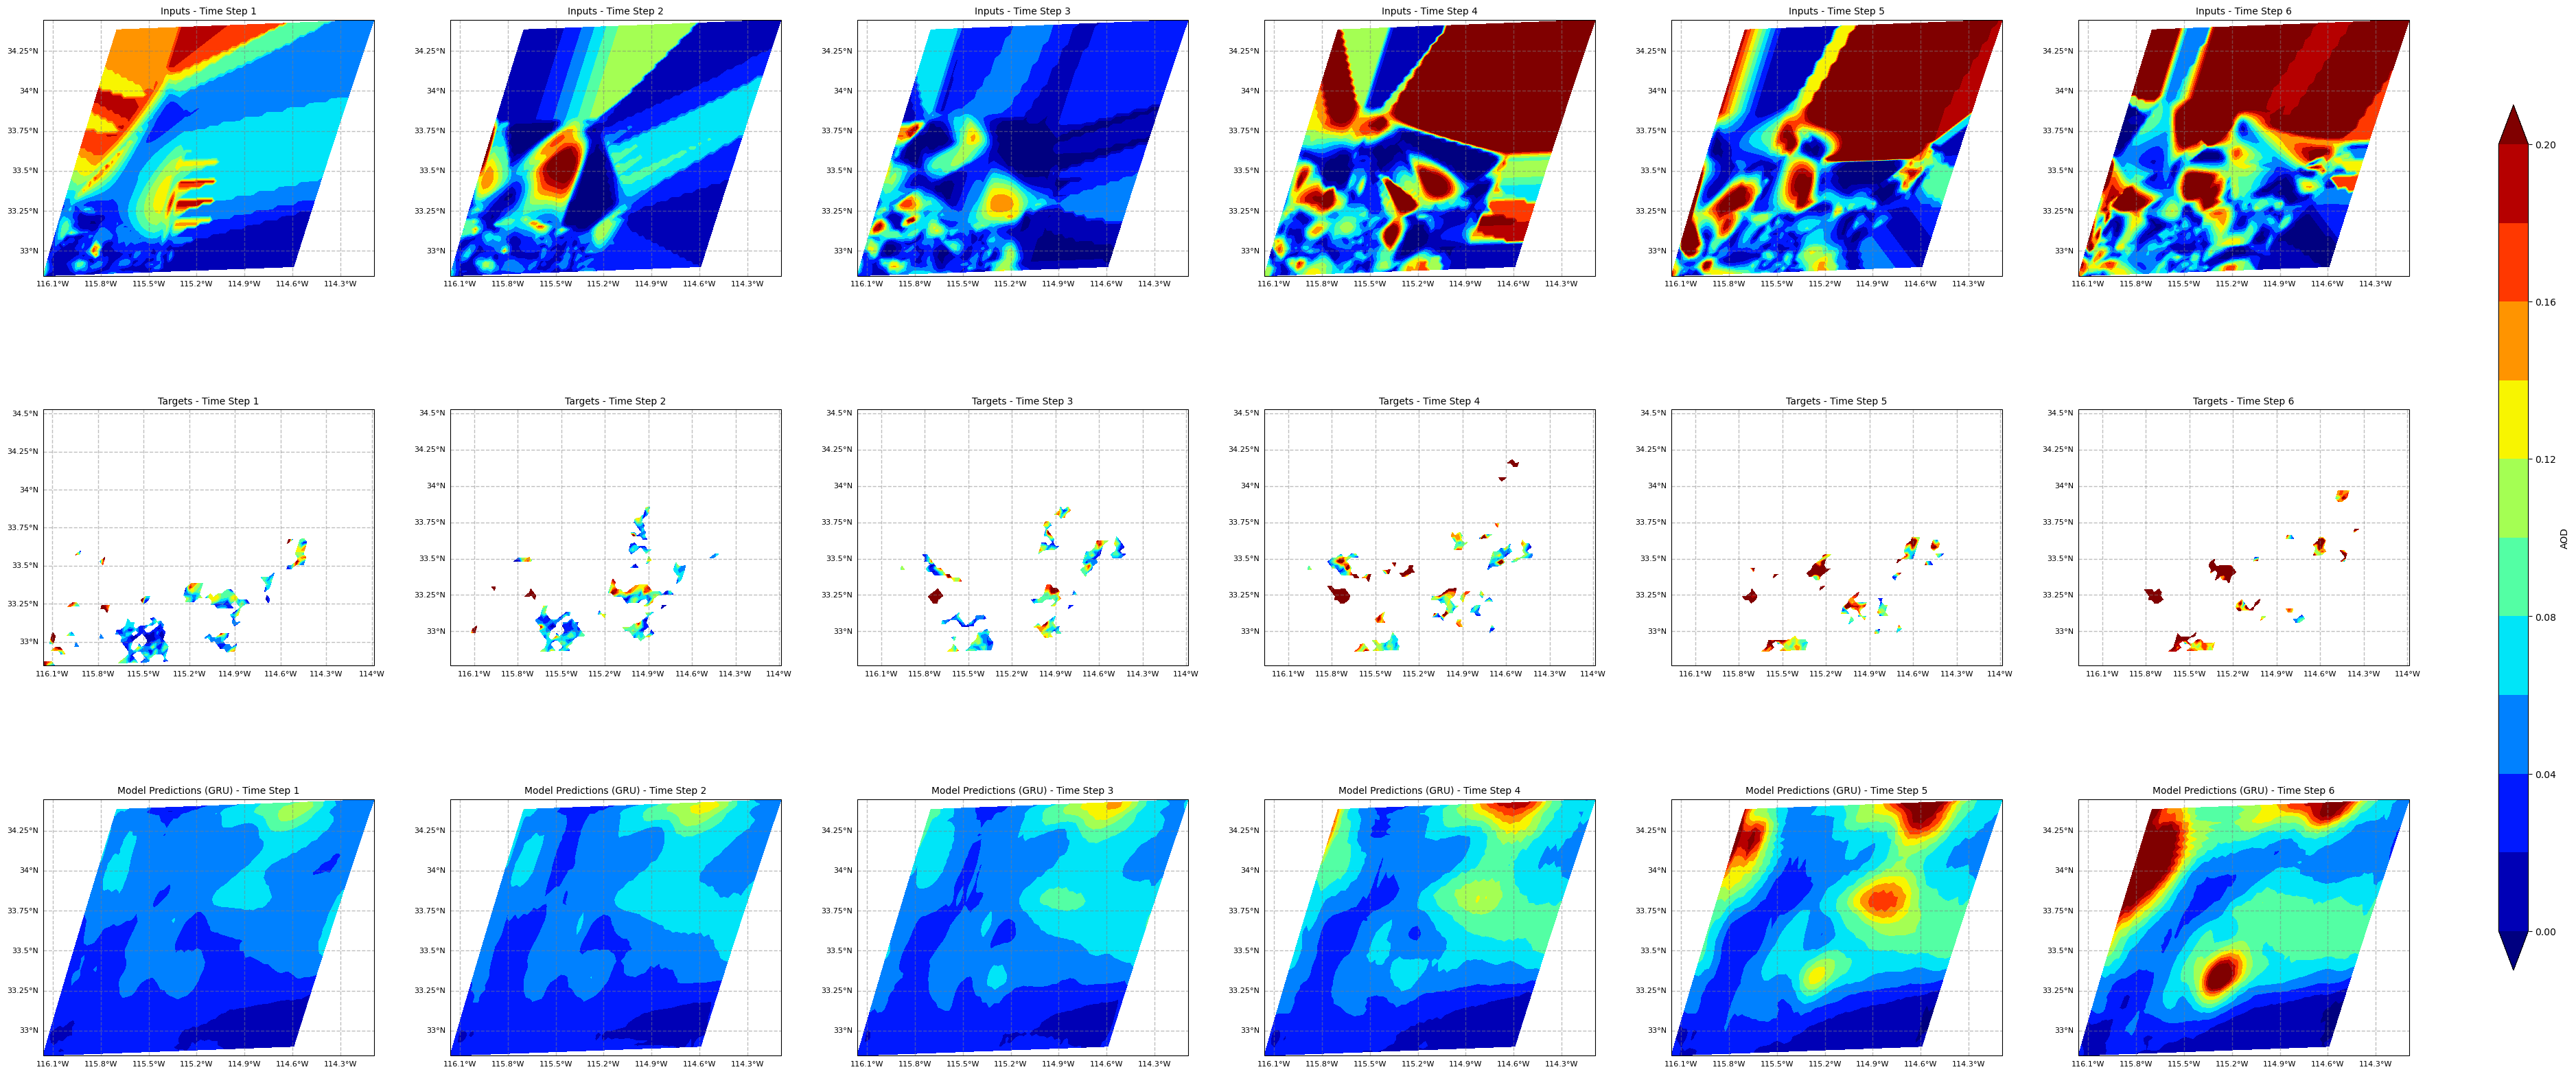

Plotting Sample 2 in batch 0...


/var/folders/91/vy36ykpj2v95bksxf2pglsy80000gn/T/ipykernel_59907/4276503074.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)


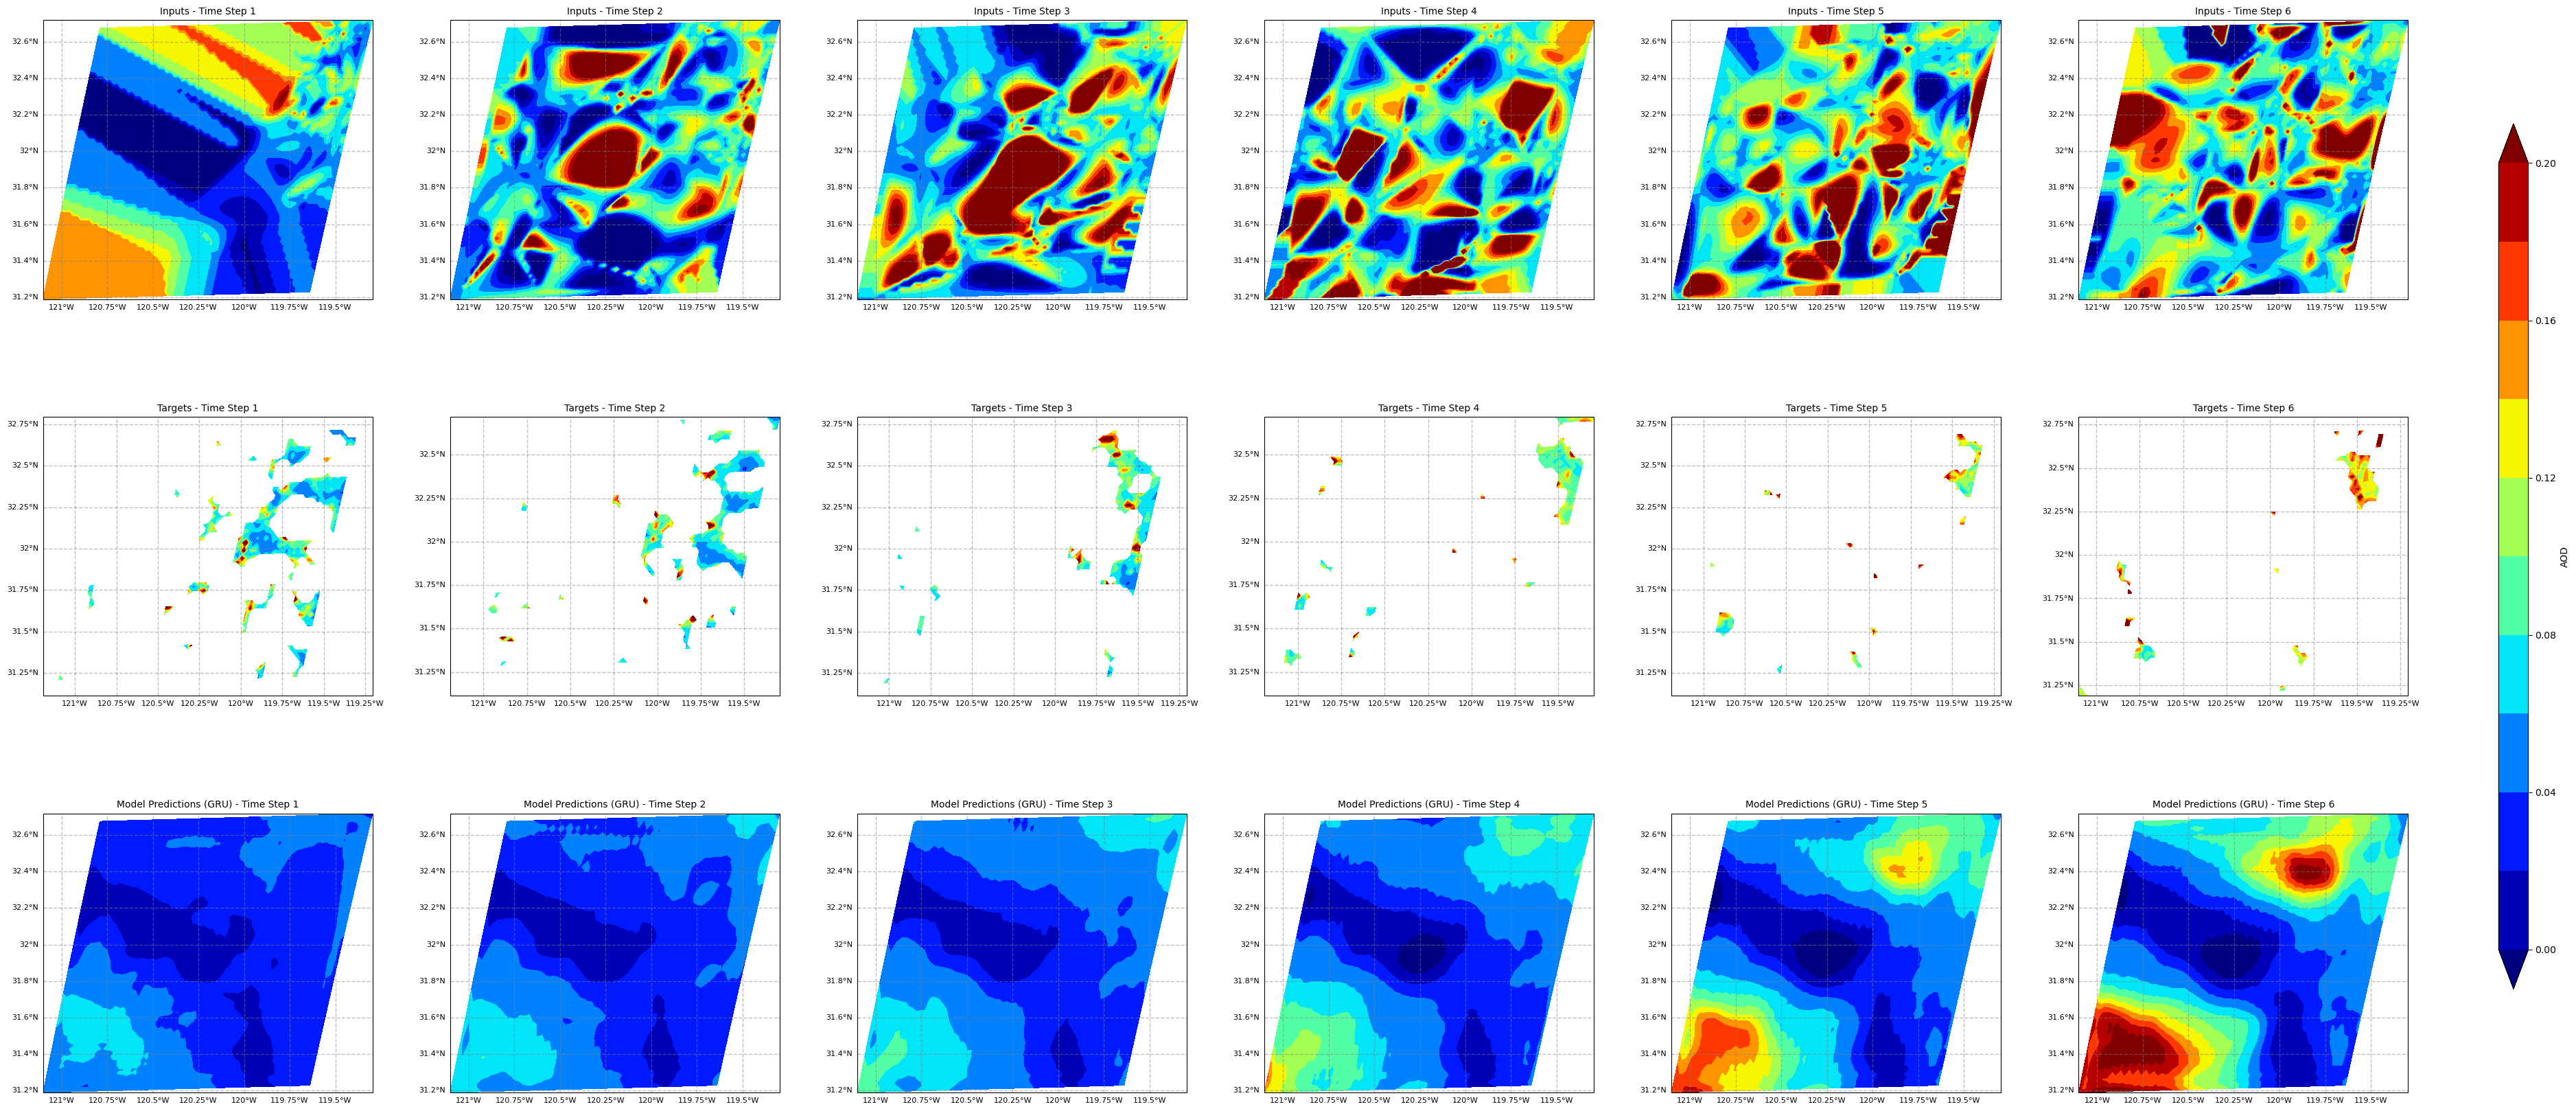

Plotting Sample 3 in batch 0...


/var/folders/91/vy36ykpj2v95bksxf2pglsy80000gn/T/ipykernel_59907/4276503074.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)


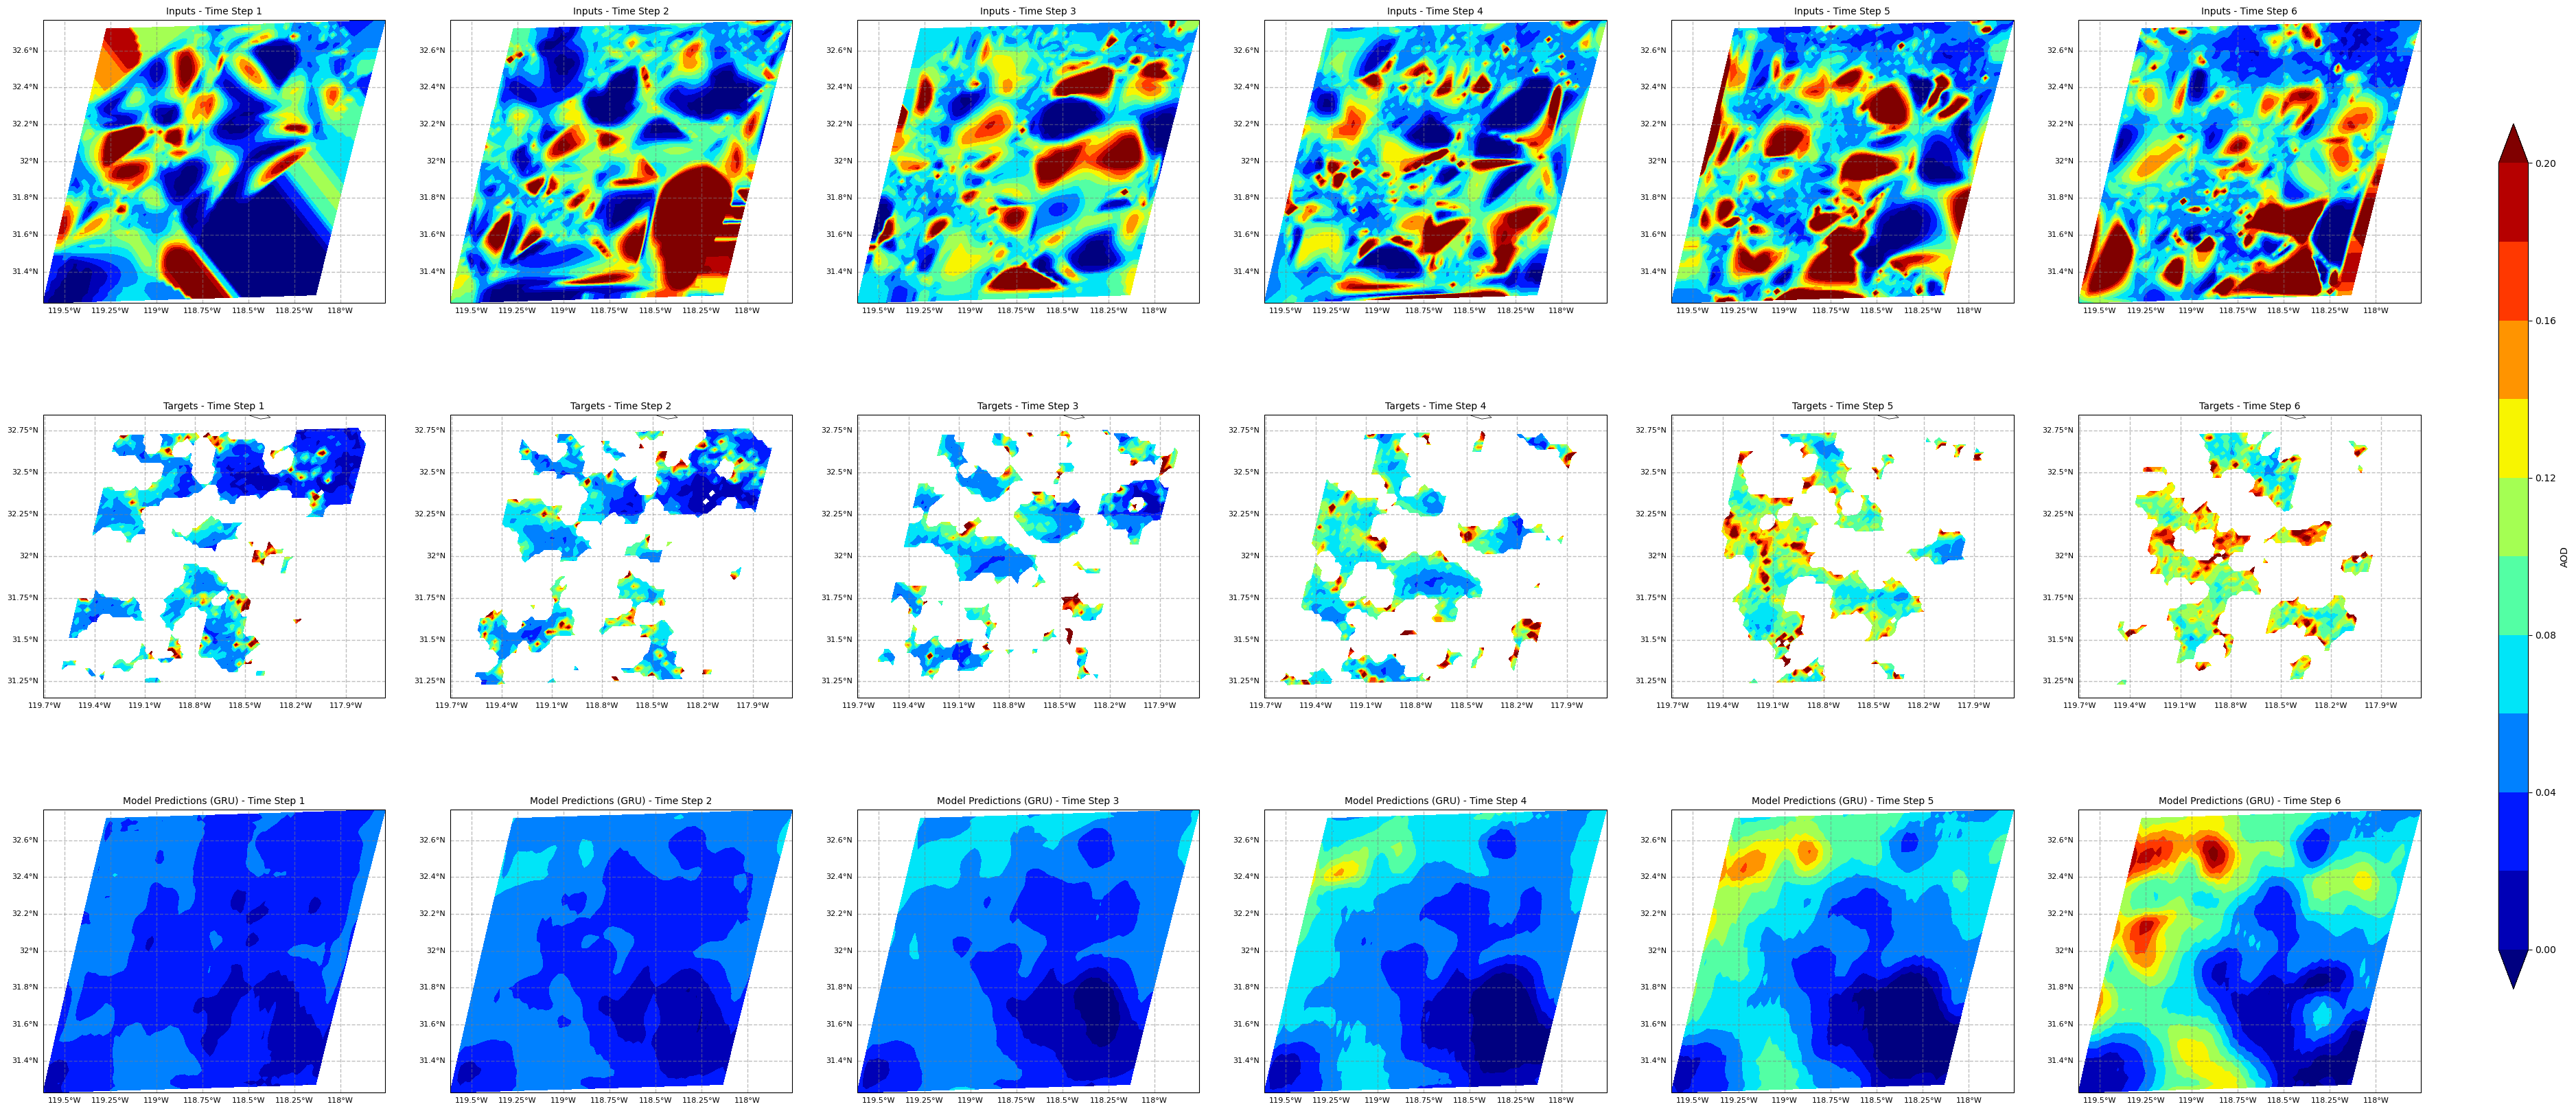

Plotting Sample 4 in batch 0...


/var/folders/91/vy36ykpj2v95bksxf2pglsy80000gn/T/ipykernel_59907/4276503074.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)


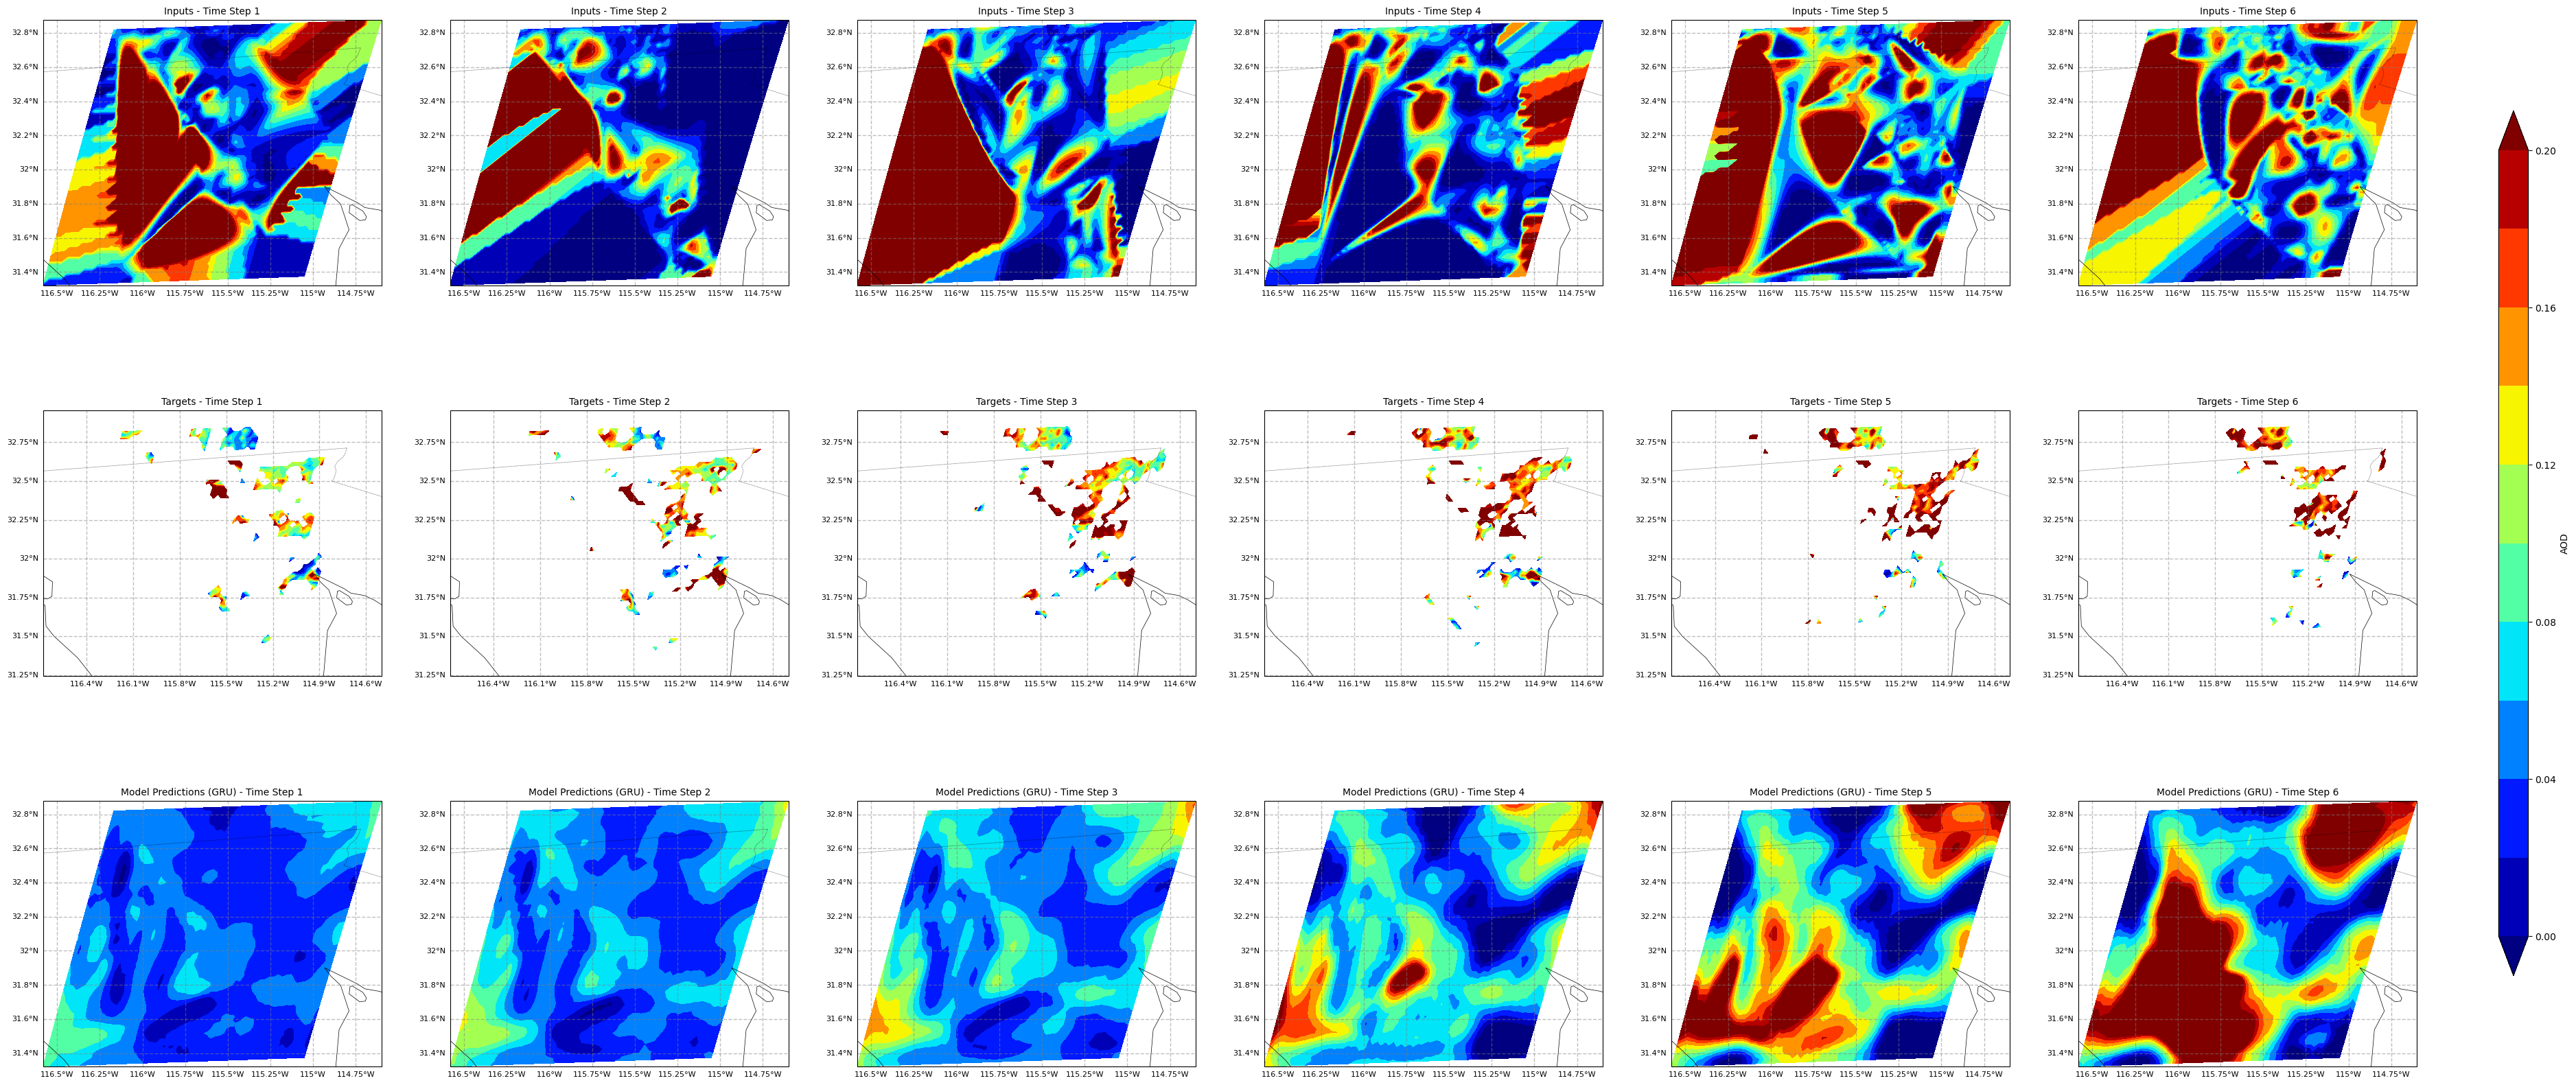

In [16]:
# plot more samples
# define which batches to plot, there are 12/5=3 batches in total
to_plot_batch_idx = range(1)  # this will plot the first 1 batches
for batch_idx in to_plot_batch_idx:
    print(f"Plotting Batch {batch_idx}...")
    # load the inputs, targets and outputs
    save_inputs_data = np.load(f'./data/save_inputs_{batch_idx*batch_size}-{(batch_idx+1)*batch_size-1}.npy')
    save_targets_data = np.load(f'./data/save_targets_{batch_idx*batch_size}-{(batch_idx+1)*batch_size-1}.npy')
    save_outputs_gru_data = np.load(f'./data/save_outputs_gru_{batch_idx*batch_size}-{(batch_idx+1)*batch_size-1}.npy')
    # save_outputs_lstm_data = np.load(f'./data/save_outputs_lstm_{batch_idx*batch_size}-{(batch_idx+1)*batch_size-1}.npy')
    # load lat and lon
    save_inputs_lat = np.load(f'./data/save_inputs_lat_{batch_idx*batch_size}-{(batch_idx+1)*batch_size-1}.npy')
    save_inputs_lon = np.load(f'./data/save_inputs_lon_{batch_idx*batch_size}-{(batch_idx+1)*batch_size-1}.npy')
    save_targets_lat = np.load(f'./data/save_targets_lat_{batch_idx*batch_size}-{(batch_idx+1)*batch_size-1}.npy')
    save_targets_lon = np.load(f'./data/save_targets_lon_{batch_idx*batch_size}-{(batch_idx+1)*batch_size-1}.npy')
    # reshape the data to (batch_size, num_frames, height, width)
    save_inputs_data = save_inputs_data.reshape(-1, 6, 64, 64)
    save_targets_data = save_targets_data.reshape(-1, 6, 64, 64)
    save_outputs_gru_data = save_outputs_gru_data.reshape(-1, 6, 64, 64)
    # save_outputs_lstm_data = save_outputs_lstm_data.reshape(-1, 6, 64, 64)
    save_inputs_lat = save_inputs_lat.reshape(-1, 6, 64, 64)
    save_inputs_lon = save_inputs_lon.reshape(-1, 6, 64, 64)
    save_targets_lat = save_targets_lat.reshape(-1, 6, 64, 64)
    save_targets_lon = save_targets_lon.reshape(-1, 6, 64, 64)
    # plot the inputs, targets and outputs
    for j in range(save_inputs_data.shape[0]):
        print(f"Plotting Sample {j} in batch {batch_idx}...")
        fig, axarr = plt.subplots(
            nrows=3,
            ncols=6,
            figsize=(6*6, 3*6),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )
        projection = ccrs.PlateCarree()
        for n in range(6):
            for k in range(3):
                ax = axarr[k][n]
                if k == 0:
                    # Plot the inputs
                    plot_img = save_inputs_data[j, n, ...]
                    lats_img = save_inputs_lat[j, n, ...]
                    lons_img = save_inputs_lon[j, n, ...]
                    title = 'Inputs'
                elif k == 1:
                    # Plot the targets
                    plot_img = save_targets_data[j, n, ...]
                    lats_img = save_targets_lat[j, n, ...]
                    lons_img = save_targets_lon[j, n, ...]
                    title = 'Targets'
                else:
                    # Plot the model predictions
                    lats_img = save_targets_lat[j, n, ...]
                    lons_img = save_targets_lon[j, n, ...]
                    plot_img = save_outputs_gru_data[j, n, ...]
                    title = 'Model Predictions (GRU)'
                    # plot_img = save_outputs_lstm_data[j, n, ...]
                    # title = 'Model Predictions (ConvLSTM)'
                # Plot the data
                cs = ax.contourf(lons_img, lats_img, plot_img,
                                 transform=projection, cmap='jet', levels=np.linspace(0, 0.2, 11), extend='both')
                # Add geographic features and labeled gridlines
                ax.coastlines(resolution='50m', color='black', linewidth=0.5)
                ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
                gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
                gl.top_labels = False
                gl.right_labels = False
                gl.xformatter = LongitudeFormatter()
                gl.yformatter = LatitudeFormatter()
                gl.xlabel_style = {'size': 8}
                gl.ylabel_style = {'size': 8}
                ax.set_title(title + f' - Time Step {n+1}', fontsize=10)
        # Add a colorbar
        # Add a single colorbar on the right side of all subplots
        fig.subplots_adjust(right=0.92)
        cbar_ax = fig.add_axes([1.02, 0.15, 0.012, 0.7])  # [left, bottom, width, height]
        cbar = plt.colorbar(cs, cax=cbar_ax)
        cbar.set_label('AOD')
        plt.tight_layout(pad=3.0)
        plt.show()